# Metodologia Design Science Research (DSR)

**Etapa de Pesquisa (Peffers et al., 2007):**
### 2. Definição dos Objetivos de uma Solução (Define Objectives) e 3. Design e Desenvolvimento

**Objetivo Acadêmico:** Este notebook cumpre o papel de fundamentação empírica e rigor científico (Ciclo de Rigor de Hevner). Através da Análise Exploratória de Dados (EDA), identificamos as correlações e padrões de bimodalidade que o artefato final deve ser capaz de capturar. A compreensão das variâncias por dia da semana e o impacto das proteínas principais são essenciais para justificar a escolha de modelos complexos como Gradiente Boosting e PNL, conforme discutido em Kim et al. (2023).


# 03 - Análise Exploratória Profunda (EDA) - Refinamento Localizado
Neste notebook, realizamos uma investigação estatística e visual dos dados consolidados, buscando entender as alavancas que movem a demanda por refeições.

**Objetivos:**
1. Analisar a sazonalidade via **Mapas de Calor Trimestrais**.
2. Estudar a variabilidade diária com **Gráficos de Violino (Violin Plots)**.
3. Quantificar o impacto das **Proteínas** e do **Clima**.
4. Auditar o **Gap de Planejamento** (Reservas vs Real).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Estilo Premium
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = [15, 6]
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16

In [2]:
# Carga da Base Mestra
df = pd.read_csv('../data/base_mestra_consolidada.csv')
df['data'] = pd.to_datetime(df['data'])

# Tradução dos Dias da Semana e Engenharia de Features
df['mes'] = df['data'].dt.month
df['trimestre'] = df['data'].dt.quarter
df['semana_ano'] = df['data'].dt.isocalendar().week

# Mapeamento para Português
mapa_dias = {
    'Monday': 'Segunda',
    'Tuesday': 'Terça',
    'Wednesday': 'Quarta',
    'Thursday': 'Quinta',
    'Friday': 'Sexta'
}
df['nome_dia'] = df['data'].dt.day_name().map(mapa_dias)
ordem_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta']

# Filtro de Dias Ativos (Ignorar fins de semana e dias sem registro histórico)
df_ativo = df[(df['tem_refeicao'] == 1) & (df['total_servido'] > 0)].copy()

print(f"Base Mestra: {len(df)} dias.")
print(f"Dias analisados (com consumo): {len(df_ativo)} dias.")

Base Mestra: 99 dias.
Dias analisados (com consumo): 99 dias.


## 1. Sazonalidade Geográfica (Mapas de Calor por Trimestre)
Visualização da densidade de demanda ao longo das semanas, segmentada por trimestre.

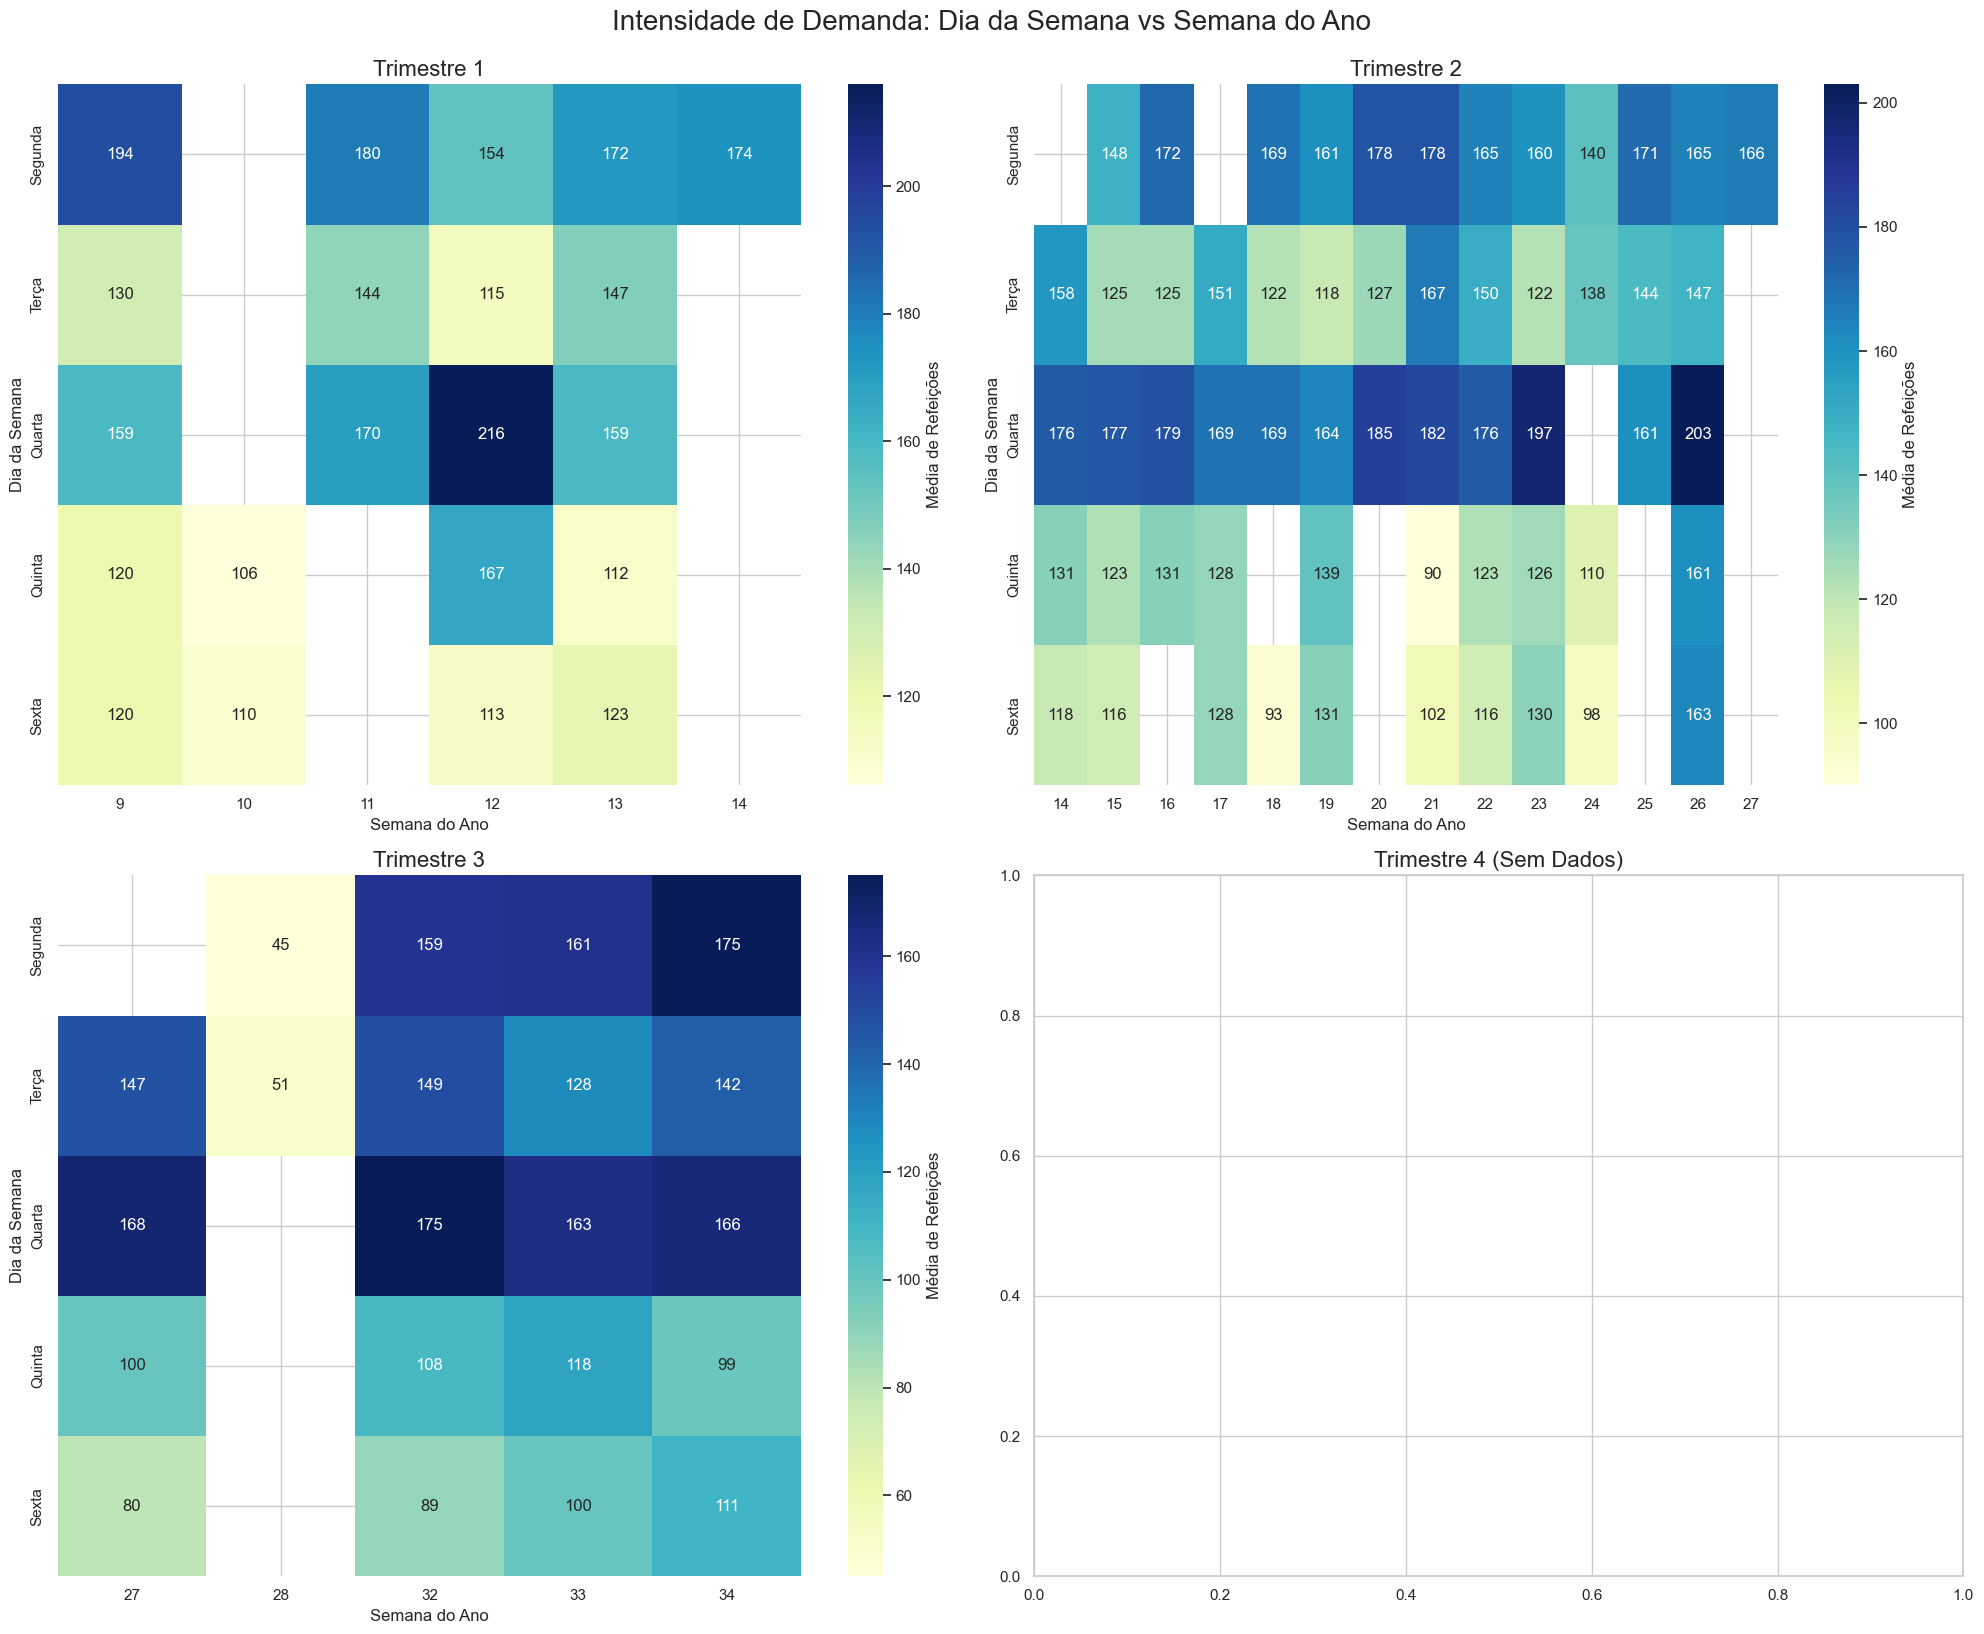

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for i, tri in enumerate([1, 2, 3, 4]):
    df_tri = df_ativo[df_ativo['trimestre'] == tri]
    if not df_tri.empty:
        pivot = df_tri.pivot_table(values='total_servido', index='nome_dia', columns='semana_ano', aggfunc='mean')
        pivot = pivot.reindex(ordem_dias)
        sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu", ax=axes[i], cbar_kws={'label': 'Média de Refeições'})
        axes[i].set_title(f"Trimestre {tri}")
        axes[i].set_ylabel("Dia da Semana")
        axes[i].set_xlabel("Semana do Ano")
    else:
        axes[i].set_title(f"Trimestre {tri} (Sem Dados)")

plt.tight_layout()
plt.suptitle("Intensidade de Demanda: Dia da Semana vs Semana do Ano", fontsize=20, y=1.02)
plt.show()

## 2. Dinâmica de Comparecimento (Distribuição Diária)
Análise da dispersão e bimodalidade do consumo por dia da semana.

C:\Users\miche\AppData\Local\Temp\ipykernel_35932\1966141521.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_ativo, x='nome_dia', y='total_servido', order=ordem_dias, inner="quart", palette="muted")


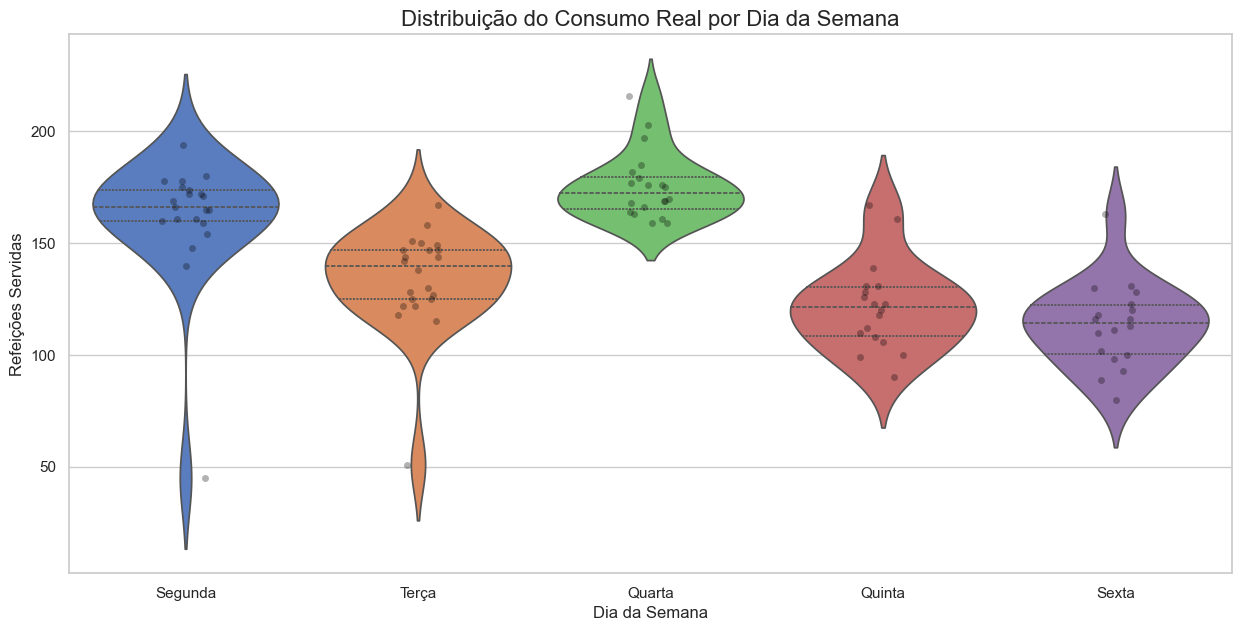

In [4]:
plt.figure(figsize=(15, 7))
sns.violinplot(data=df_ativo, x='nome_dia', y='total_servido', order=ordem_dias, inner="quart", palette="muted")
sns.stripplot(data=df_ativo, x='nome_dia', y='total_servido', order=ordem_dias, color="black", alpha=0.3)
plt.title("Distribuição do Consumo Real por Dia da Semana")
plt.ylabel("Refeições Servidas")
plt.xlabel("Dia da Semana")
plt.show()

## 3. Atração do Cardápio (Impacto da Proteína)
Como a proteína principal influencia a decisão de comparecimento?

C:\Users\miche\AppData\Local\Temp\ipykernel_35932\1660732478.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ativo, x='proteina_label', y='total_servido', palette="Set2")


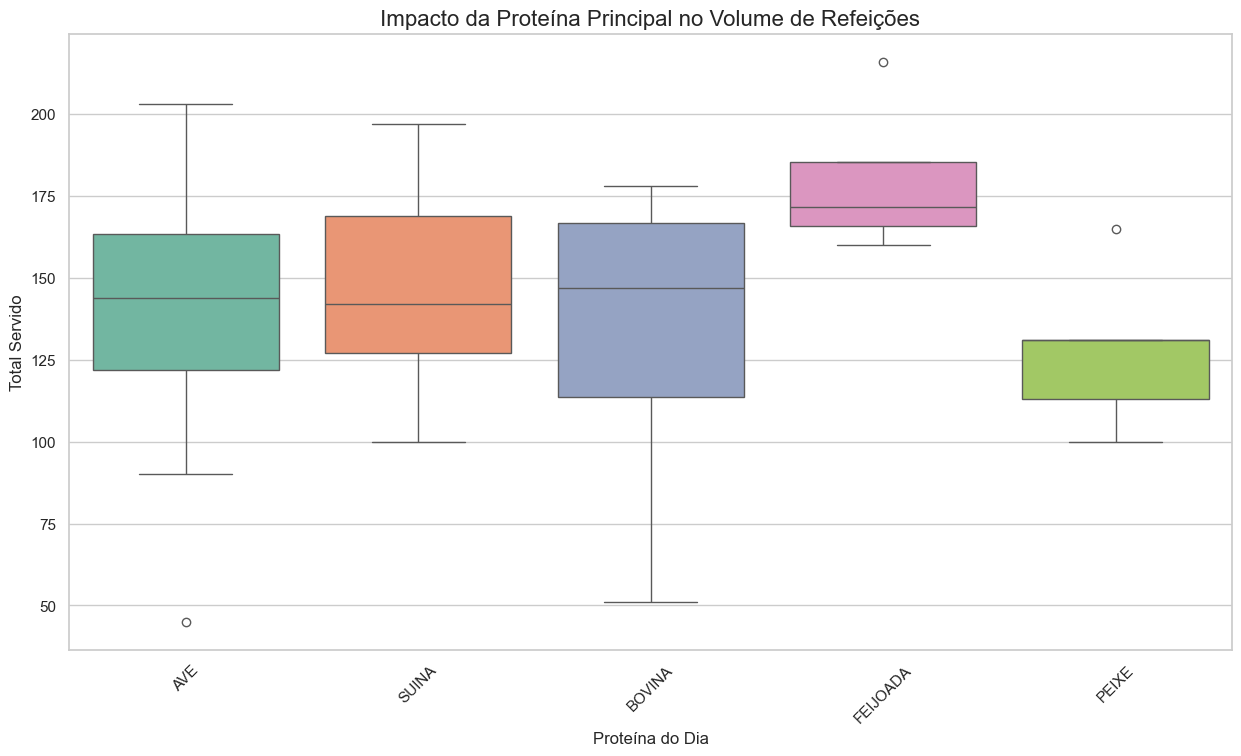

In [5]:
# Agrupar proteínas raras em 'OUTROS'
top_proteinas = df_ativo['proteina_principal'].value_counts().nlargest(6).index
df_ativo['proteina_label'] = df_ativo['proteina_principal'].apply(lambda x: x if x in top_proteinas else 'OUTROS')

plt.figure(figsize=(15, 8))
sns.boxplot(data=df_ativo, x='proteina_label', y='total_servido', palette="Set2")
plt.xticks(rotation=45)
plt.title("Impacto da Proteína Principal no Volume de Refeições")
plt.ylabel("Total Servido")
plt.xlabel("Proteína do Dia")
plt.show()

## 4. Fatores Climáticos (Temperatura e Chuva)
Correlação entre variáveis ambientais e o volume de consumo.

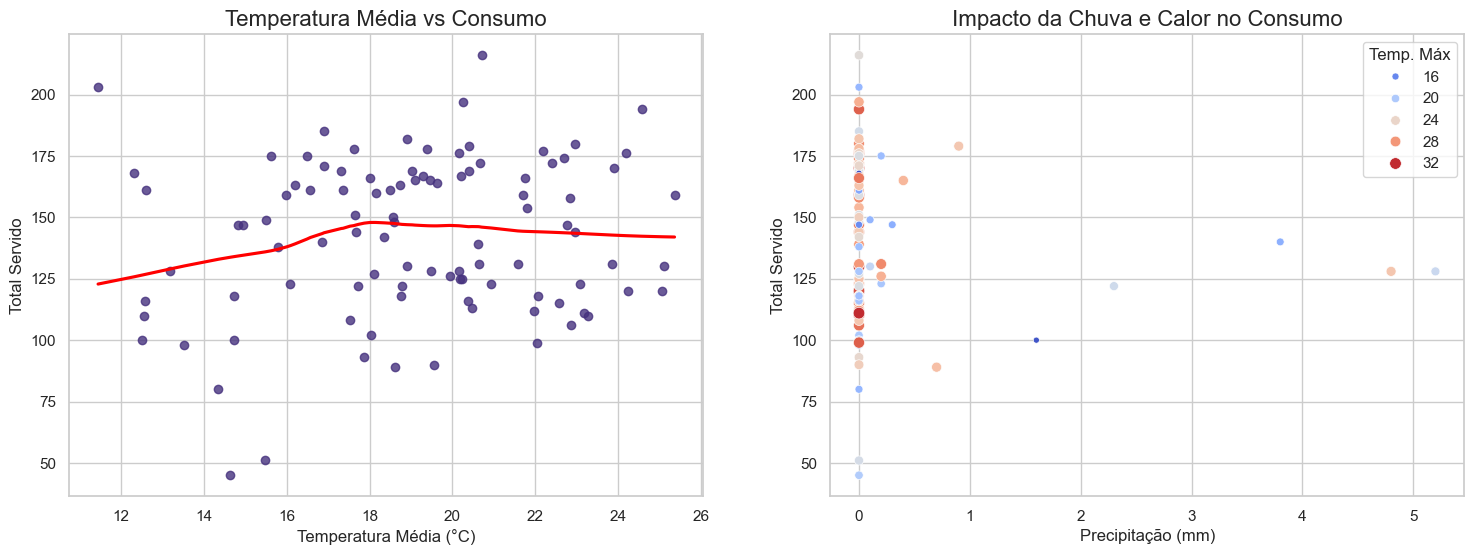

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.regplot(data=df_ativo, x='temp_media', y='total_servido', ax=axes[0], lowess=True, line_kws={'color':'red'})
axes[0].set_title("Temperatura Média vs Consumo")
axes[0].set_xlabel("Temperatura Média (°C)")
axes[0].set_ylabel("Total Servido")

sns.scatterplot(data=df_ativo, x='chuva_soma', y='total_servido', size='temp_max', hue='temp_max', ax=axes[1], palette="coolwarm")
axes[1].set_title("Impacto da Chuva e Calor no Consumo")
axes[1].set_xlabel("Precipitação (mm)")
axes[1].set_ylabel("Total Servido")
axes[1].legend(title="Temp. Máx")

plt.show()

## 5. Auditoria de Planejamento (Reservas vs Real) por Trimestre
Análise do hiato entre a intenção de consumo e a efetivação do serviço, segmentada para identificar padrões sazonais de desperdício ou subestimativa.

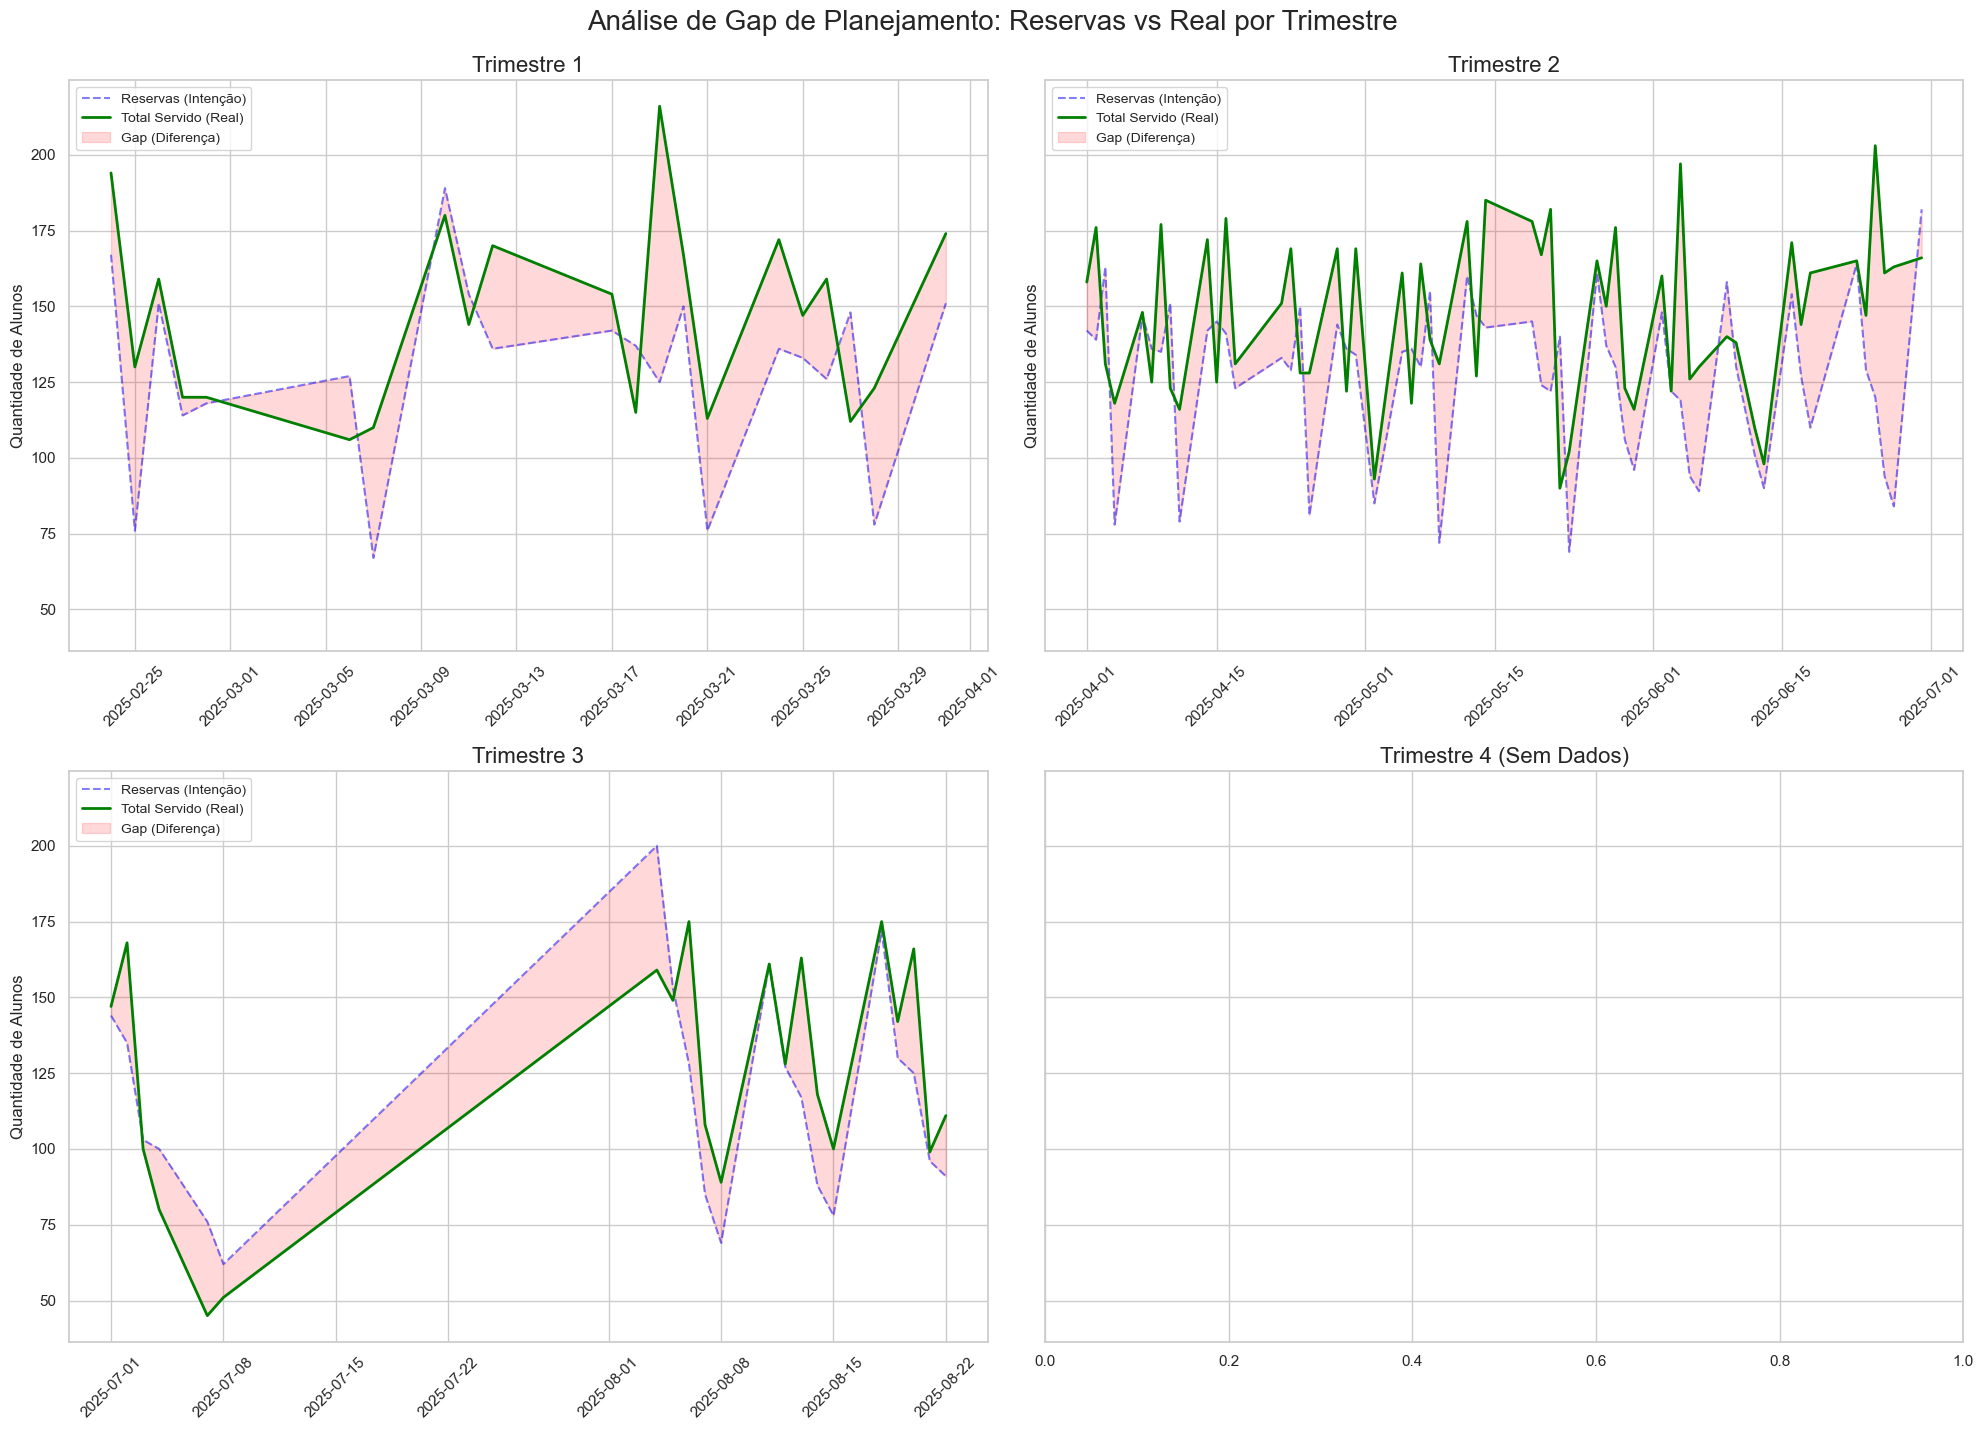

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14), sharey=True)
axes = axes.flatten()

for i, tri in enumerate([1, 2, 3, 4]):
    df_tri = df_ativo[df_ativo['trimestre'] == tri].sort_values('data')
    
    if not df_tri.empty:
        axes[i].plot(df_tri['data'], df_tri['total_reservas'], label='Reservas (Intenção)', color='blue', linestyle='--', alpha=0.5)
        axes[i].plot(df_tri['data'], df_tri['total_servido'], label='Total Servido (Real)', color='green', linewidth=2)
        axes[i].fill_between(df_tri['data'], df_tri['total_servido'], df_tri['total_reservas'], color='red', alpha=0.15, label='Gap (Diferença)')
        
        axes[i].set_title(f"Trimestre {tri}")
        axes[i].legend(loc='upper left', fontsize=10)
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_ylabel("Quantidade de Alunos")
    else:
        axes[i].set_title(f"Trimestre {tri} (Sem Dados)")

plt.tight_layout()
plt.suptitle("Análise de Gap de Planejamento: Reservas vs Real por Trimestre", fontsize=20, y=10.2 / 10)
plt.show()

## 6. Auditoria Detalhada de Fluxo por Mês (Comparecimento e Consumo Adicional)
Esta tabela apresenta a agregação mensal das métricas de comparecimento, comparando o volume de reservas com o consumo real efetivado.

In [8]:
# Agrupar métricas por Mês
df_ativo['ano_mes'] = df_ativo['data'].dt.strftime('%Y-%m')

df_auditoria_mensal = df_ativo.groupby('ano_mes').agg({
    'total_reservas': 'sum',
    'total_servido': 'sum',
    'nao_reservou_e_comeu': 'sum'
}).sort_index(ascending=False)

# Renomear colunas para Português amigável
df_auditoria_mensal.columns = [
    'Total Reservas', 'Consumo Real', 'Consumo Adicional (Sem Reserva)'
]

# Calcular % de Consumo Adicional sobre o Total
df_auditoria_mensal['% Adicional'] = (df_auditoria_mensal['Consumo Adicional (Sem Reserva)'] / df_auditoria_mensal['Consumo Real'] * 100).round(1)

print("Tabela de Auditoria Mensal (Perfil de Demanda):")
display(df_auditoria_mensal.style.background_gradient(cmap='YlOrRd', subset=['Consumo Adicional (Sem Reserva)', '% Adicional']))

Tabela de Auditoria Mensal (Perfil de Demanda):


,Total Reservas,Consumo Real,Consumo Adicional (Sem Reserva),% Adicional
ano_mes,,,,
2025-08,1820,2043,848,41.500000
2025-07,620,591,284,48.100000
2025-06,2215,2702,1275,47.200000
2025-05,2393,2745,1168,42.600000
2025-04,2628,2915,1158,39.700000
2025-03,2075,2362,954,40.400000
2025-02,626,723,211,29.200000
